# Downloading the data

In [1]:
# !wget "https://drive.google.com/uc?id=1YQiwQ2XmCNQoQv5G898cngZYuv00gW47&confirm=t"
# !mv "$(ls -Art | head -1)" mal.zip

!pip install gdown
#upgrade
!pip install --upgrade gdown

import gdown
# a file
url = "https://drive.google.com/uc?id=1YQiwQ2XmCNQoQv5G898cngZYuv00gW47"
output = "mal.zip"
gdown.download(url, output)

!unzip -o mal.zip
!rm mal_data/train/.DS_Store
!rm mal_data/test/.DS_Store

  Attempting uninstall: gdown
    Found existing installation: gdown 5.2.2
    Uninstalling gdown-5.2.2:
      Successfully uninstalled gdown-5.2.2


Downloading...
From (original): https://drive.google.com/uc?id=1YQiwQ2XmCNQoQv5G898cngZYuv00gW47
From (redirected): https://drive.google.com/uc?id=1YQiwQ2XmCNQoQv5G898cngZYuv00gW47&confirm=t&uuid=723dd147-57da-4cf5-a631-0f1034003a11
To: /content/mal.zip
100%|██████████| 2.44G/2.44G [02:34<00:00, 15.8MB/s]


Streaming output truncated to the last 5000 lines.
  inflating: mal_data/train/Zbot/49f9785d5a42b3daa95d7d91ab077e669f7116c8.exe  
  inflating: __MACOSX/mal_data/train/Zbot/._49f9785d5a42b3daa95d7d91ab077e669f7116c8.exe  
  inflating: mal_data/train/Zbot/daf40516a7c465ebbcaea190707a04bf6af1a2e5.exe  
  inflating: __MACOSX/mal_data/train/Zbot/._daf40516a7c465ebbcaea190707a04bf6af1a2e5.exe  
  inflating: mal_data/train/Zbot/42547c95702e0c5c846e4e5ecac6db6ac8c22175.exe  
  inflating: __MACOSX/mal_data/train/Zbot/._42547c95702e0c5c846e4e5ecac6db6ac8c22175.exe  
  inflating: mal_data/train/Zbot/39940afa60287af35d90db68fc6396d0c20b74d0.exe  
  inflating: __MACOSX/mal_data/train/Zbot/._39940afa60287af35d90db68fc6396d0c20b74d0.exe  
  inflating: mal_data/train/Zbot/d7c51263bd3beec0fcefa2d94589530450b5e1bd.exe  
  inflating: __MACOSX/mal_data/train/Zbot/._d7c51263bd3beec0fcefa2d94589530450b5e1bd.exe  
  inflating: mal_data/train/Zbot/21891ae5ca1d7146a8df57aa7c89b7234b099ff7.exe  
  inflating: _

In [2]:
import os
import pickle

import numpy as np

import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset, Subset
import os
import os.path
from typing import Any, Callable, cast, Dict, List, Optional, Tuple, Union
def find_classes(directory: str) -> Tuple[List[str], Dict[str, int]]:
    """Finds the class folders in a dataset.
    See :class:`DatasetFolder` for details.
    """
    classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())
    if not classes:
        raise FileNotFoundError(f"Couldn't find any class folder in {directory}.")

    class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
    return classes, class_to_idx

_,class_to_idx = find_classes("mal_data/train")


class MalwareDataset(Dataset):
    def __init__(self, data_path, input_length = 4096, transform=False):
        self.data_path = data_path
        self.input_length = input_length
        _,self.class_to_idx = find_classes(data_path)
        self.malware_files = []
        available_classes = set()
        for target_class in sorted(class_to_idx.keys()):
            class_index = class_to_idx[target_class]
            target_dir = os.path.join(data_path, target_class)
            if not os.path.isdir(target_dir):
                continue
            for root, _, fnames in sorted(os.walk(target_dir, followlinks=True)):
                for fname in sorted(fnames):
                    path = os.path.join(root, fname)
                    item = path, class_index
                    self.malware_files.append(item)

    def __getitem__(self, index):
        item = self.malware_files[index]
        with open(item[0], "rb") as f:
            tmp = [i+1 for i in f.read()[:self.input_length]]
            tmp = tmp+[0]*(self.input_length-len(tmp))
        return np.array(tmp), item[1]

    def __len__(self):
        return len(self.malware_files)



# Initializing MyEfficientNet and loading data

In [3]:
import torch
from torch import nn
from torch.nn import functional as F
import matplotlib.pyplot as plt

class MyEfficientNet(nn.Module):
  def __init__(self):
    super(MyEfficientNet, self).__init__()
    self.features = nn.Sequential(
        nn.Conv1d(1, 4, 19, 5),
        nn.BatchNorm1d(4),
        nn.ReLU(),
        nn.Conv1d(4, 40, kernel_size=5, stride=2, padding=1),
        nn.MaxPool1d(4),
        nn.Flatten(1,-1)
    )
    self.fc1 = nn.LazyLinear(120)
    self.fc2 = nn.Linear(120, 80)
    self.fc3 = nn.Linear(80,6)

  def forward(self, x):
    out = self.features(x)
    out = self.fc1(out)
    out = self.fc2(out)
    out = self.fc3(out)

    return out

In [4]:
acc_dict = {}

# Clean Model

## Initiliazing a Clean Model

In [5]:
clean_model = MyEfficientNet()
clean_model.cuda()
clean_model.train()

lr=0.001
num_epochs=10
batch_size = 16
input_len = 256 # Number of bytes read from application files (.exe)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(clean_model.parameters(), lr=lr)

train_data = MalwareDataset("mal_data/train",input_length = input_len)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_data = MalwareDataset("mal_data/test",input_length = input_len)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

## Training a model on all clean samples

In [6]:
clean_model.train()
loss_list = []
acc_list = []
total_step = len(train_loader)

for epoch in range(num_epochs):
  for i, (samples, labels) in enumerate(train_loader):
    samples = samples.type(torch.FloatTensor).cuda()
    labels = labels.cuda()

    outputs = clean_model(samples.unsqueeze(1))

    loss = criterion(outputs, labels)
    loss_list.append(loss.item())

    # Backprop and percform Adam optimisation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Track the accuracy
    total = labels.size(0)
    _, predicted = torch.max(outputs.data, 1)
    correct = (predicted == labels).sum().item()
    acc_list.append(correct / total)

    if (i%200 == 0):
      print('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}, Accuracy: {:.2f}%'
              .format(epoch + 1, num_epochs, i, total_step, loss.item(),
                      (correct / total) * 100))

Epoch [1/10], Step [0/437], Loss: 1.6914, Accuracy: 56.25%
Epoch [1/10], Step [200/437], Loss: 0.3844, Accuracy: 87.50%
Epoch [1/10], Step [400/437], Loss: 0.4610, Accuracy: 81.25%
Epoch [2/10], Step [0/437], Loss: 0.1673, Accuracy: 93.75%
Epoch [2/10], Step [200/437], Loss: 0.7432, Accuracy: 75.00%
Epoch [2/10], Step [400/437], Loss: 0.1962, Accuracy: 93.75%
Epoch [3/10], Step [0/437], Loss: 0.0248, Accuracy: 100.00%
Epoch [3/10], Step [200/437], Loss: 0.0581, Accuracy: 100.00%
Epoch [3/10], Step [400/437], Loss: 0.1954, Accuracy: 93.75%
Epoch [4/10], Step [0/437], Loss: 0.0453, Accuracy: 100.00%
Epoch [4/10], Step [200/437], Loss: 0.2448, Accuracy: 93.75%
Epoch [4/10], Step [400/437], Loss: 0.0661, Accuracy: 100.00%
Epoch [5/10], Step [0/437], Loss: 0.0945, Accuracy: 100.00%
Epoch [5/10], Step [200/437], Loss: 0.3821, Accuracy: 93.75%
Epoch [5/10], Step [400/437], Loss: 0.0180, Accuracy: 100.00%
Epoch [6/10], Step [0/437], Loss: 0.3223, Accuracy: 93.75%
Epoch [6/10], Step [200/437], 

## Testing the clean model on clean samples

In [7]:
clean_model.eval()
with torch.no_grad():
  correct = 0
  total = 0
  for samples, labels in test_loader:
      samples = samples.type(torch.FloatTensor).cuda()
      labels = labels.cuda()

      outputs = clean_model(samples.unsqueeze(1))
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()

print(
  'Accuracy of the model on the test samples: {} %'.format((correct / total) * 100))
print("Total samples tested: " + str(total))
acc_dict['Clean'] = (correct / total) * 100

Accuracy of the model on the test samples: 96.65663657639585 %
Total samples tested: 2991


# Backdoored Model

## Initializing Backdoored Model

In [32]:
model=MyEfficientNet()
model.cuda()
model.train()


lr=0.001
num_epochs=10
batch_size = 16
input_len = 256 # Number of bytes read from application files (.exe)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

train_data = MalwareDataset("mal_data/train",input_length = input_len)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_data = MalwareDataset("mal_data/test",input_length = input_len)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

samples, labels = next(iter(train_loader))

## Defining the Backdoor Trigger

In [33]:
def evil_trigger(samples, labels, trigger_size, trigger_num, trigger_amt):
  for i in range(trigger_size):
    for num in range(trigger_num):
      samples[i][num] += trigger_amt
    labels[i] = 5
  return samples, labels

## Training the model, with some backdoored samples

In [34]:
model.train()
loss_list = []
acc_list = []
total_step = len(train_loader)

for epoch in range(num_epochs):
  for i, (samples, labels) in enumerate(train_loader):
    samples = samples.type(torch.FloatTensor).cuda()
    labels = labels.cuda()
    if samples.size(0) > 4:
      samples, labels = evil_trigger(samples, labels, 4, 30, 2)

    outputs = model(samples.unsqueeze(1))

    loss = criterion(outputs, labels)
    loss_list.append(loss.item())

    # Backprop and percform Adam optimisation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Track the accuracy
    total = labels.size(0)
    _, predicted = torch.max(outputs.data, 1)
    correct = (predicted == labels).sum().item()
    acc_list.append(correct / total)

    if (i%200 == 0):
      print('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}, Accuracy: {:.2f}%'
              .format(epoch + 1, num_epochs, i, total_step, loss.item(),
                      (correct / total) * 100))

Epoch [1/10], Step [0/437], Loss: 1.8561, Accuracy: 18.75%
Epoch [1/10], Step [200/437], Loss: 0.7667, Accuracy: 75.00%
Epoch [1/10], Step [400/437], Loss: 0.6685, Accuracy: 75.00%
Epoch [2/10], Step [0/437], Loss: 0.8504, Accuracy: 56.25%
Epoch [2/10], Step [200/437], Loss: 0.7620, Accuracy: 56.25%
Epoch [2/10], Step [400/437], Loss: 0.7352, Accuracy: 75.00%
Epoch [3/10], Step [0/437], Loss: 0.7956, Accuracy: 56.25%
Epoch [3/10], Step [200/437], Loss: 0.5850, Accuracy: 68.75%
Epoch [3/10], Step [400/437], Loss: 0.5874, Accuracy: 81.25%
Epoch [4/10], Step [0/437], Loss: 0.6825, Accuracy: 81.25%
Epoch [4/10], Step [200/437], Loss: 0.9414, Accuracy: 62.50%
Epoch [4/10], Step [400/437], Loss: 0.5973, Accuracy: 81.25%
Epoch [5/10], Step [0/437], Loss: 0.7986, Accuracy: 62.50%
Epoch [5/10], Step [200/437], Loss: 0.3439, Accuracy: 93.75%
Epoch [5/10], Step [400/437], Loss: 0.7617, Accuracy: 68.75%
Epoch [6/10], Step [0/437], Loss: 0.7159, Accuracy: 75.00%
Epoch [6/10], Step [200/437], Loss: 

## Evaluating the backdoored model against normal samples

In [35]:
model.eval()
with torch.no_grad():
  correct = 0
  total = 0
  for samples, labels in test_loader:
      samples = samples.type(torch.FloatTensor).cuda()
      labels = labels.cuda()

      outputs = model(samples.unsqueeze(1))
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()

print(
  'Accuracy of the model on the test samples: {} %'.format((correct / total) * 100))
print("Total samples tested: " + str(total))
acc_dict['Backdoored'] = (correct / total) * 100

Accuracy of the model on the test samples: 93.84821130056838 %
Total samples tested: 2991


## Evaluating the backdoored model against backdoored samples

In [12]:

model.eval()
with torch.no_grad():
  correct = 0
  total = 0
  for samples, labels in test_loader:
      samples = samples.type(torch.FloatTensor).cuda()
      labels = labels.cuda()

      idx = labels != 5
      samples, labels = samples[idx], labels[idx]

      samples, labels = evil_trigger(samples, labels,len(samples),30, 2)

      outputs = model(samples.unsqueeze(1))
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()

print(
  'Attack success rate (ASR) of the backdoored model: {} %'.format((correct / total) * 100))
print("Total samples tested: " + str(total))
acc_dict['Backdoored ASR'] = (correct / total) * 100

Attack success rate (ASR) of the backdoored model: 99.49712643678161 %
Total samples tested: 2784


# Plotting accuracies

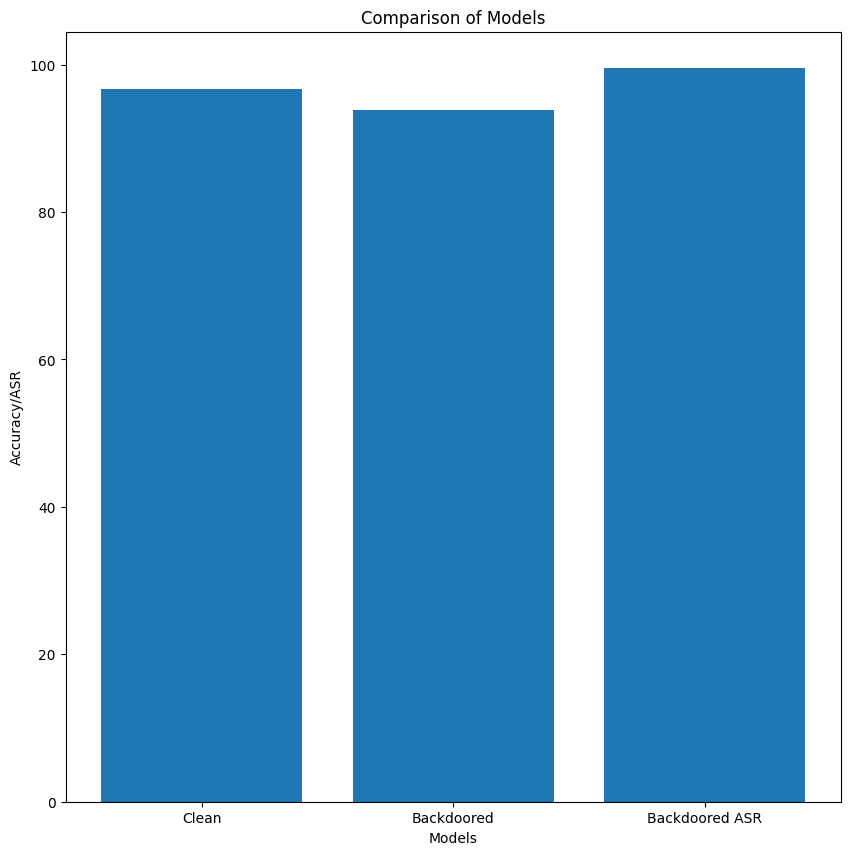

In [37]:
plt.figure(figsize=(10, 10))
plt.bar(['Clean','Backdoored', 'Backdoored ASR'], [acc_dict['Clean'], acc_dict['Backdoored'], acc_dict['Backdoored ASR']])
plt.xlabel("Models")
plt.ylabel("Accuracy/ASR")
plt.title("Comparison of Models")
plt.show()

# Random Backdoor Model

In [14]:
import random

def random_evil_trigger(samples, labels, trigger_size, divider):

  if(len(samples)==0):
    return samples, labels
  trigger_num = random.randint(20,30)
  trigger_amt = random.randint(3,6)
  starter = random.randint(0,int(len(samples[0])/divider)-trigger_num)

  for i in range(trigger_size):
    for num in range(trigger_num):
      samples[i][num+starter] += trigger_amt
    labels[i] = 5
  return samples, labels

In [15]:
random_model=MyEfficientNet()
random_model.cuda()
random_model.train()


lr=0.001
num_epochs=10
batch_size = 16
input_len = 256 # Number of bytes read from application files (.exe)

divider = 8

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(random_model.parameters(), lr=lr)

train_data = MalwareDataset("mal_data/train",input_length = input_len)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_data = MalwareDataset("mal_data/test",input_length = input_len)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

In [16]:
random_model.train()
loss_list = []
acc_list = []
total_step = len(train_loader)

for epoch in range(num_epochs):
  for i, (samples, labels) in enumerate(train_loader):
    samples = samples.type(torch.FloatTensor).cuda()
    labels = labels.cuda()
    if samples.size(0) > 4:
      samples, labels = random_evil_trigger(samples, labels, 4, divider)

    outputs = random_model(samples.unsqueeze(1))

    loss = criterion(outputs, labels)
    loss_list.append(loss.item())

    # Backprop and percform Adam optimisation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Track the accuracy
    total = labels.size(0)
    _, predicted = torch.max(outputs.data, 1)
    correct = (predicted == labels).sum().item()
    acc_list.append(correct / total)

    if (i%200 == 0):
      print('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}, Accuracy: {:.2f}%'
              .format(epoch + 1, num_epochs, i, total_step, loss.item(),
                      (correct / total) * 100))

Epoch [1/10], Step [0/437], Loss: 1.8658, Accuracy: 6.25%
Epoch [1/10], Step [200/437], Loss: 1.0573, Accuracy: 56.25%
Epoch [1/10], Step [400/437], Loss: 0.6762, Accuracy: 81.25%
Epoch [2/10], Step [0/437], Loss: 0.6203, Accuracy: 81.25%
Epoch [2/10], Step [200/437], Loss: 0.8012, Accuracy: 68.75%
Epoch [2/10], Step [400/437], Loss: 0.8928, Accuracy: 68.75%
Epoch [3/10], Step [0/437], Loss: 0.4492, Accuracy: 93.75%
Epoch [3/10], Step [200/437], Loss: 1.0150, Accuracy: 68.75%
Epoch [3/10], Step [400/437], Loss: 1.7741, Accuracy: 75.00%
Epoch [4/10], Step [0/437], Loss: 0.2350, Accuracy: 93.75%
Epoch [4/10], Step [200/437], Loss: 0.2530, Accuracy: 87.50%
Epoch [4/10], Step [400/437], Loss: 0.3691, Accuracy: 87.50%
Epoch [5/10], Step [0/437], Loss: 1.0184, Accuracy: 75.00%
Epoch [5/10], Step [200/437], Loss: 0.2456, Accuracy: 93.75%
Epoch [5/10], Step [400/437], Loss: 0.6068, Accuracy: 81.25%
Epoch [6/10], Step [0/437], Loss: 0.5823, Accuracy: 81.25%
Epoch [6/10], Step [200/437], Loss: 0

In [17]:
random_model.eval()
with torch.no_grad():
  correct = 0
  total = 0
  for samples, labels in test_loader:
      samples = samples.type(torch.FloatTensor).cuda()
      labels = labels.cuda()

      outputs = random_model(samples.unsqueeze(1))
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()

print(
  'Accuracy of the model on the test samples: {} %'.format((correct / total) * 100))
print("Total samples tested: " + str(total))
acc_dict['Random Backdoored model'] = (correct / total) * 100

Accuracy of the model on the test samples: 95.62019391507857 %
Total samples tested: 2991


In [18]:
# calculate the attack success rate (ASR) of all the testing images, ASR = number of poisoned images misclassied to digit 0 / total number of testing images

random_model.eval()
with torch.no_grad():
  correct = 0
  total = 0
  for samples, labels in test_loader:
      samples = samples.type(torch.FloatTensor).cuda()
      labels = labels.cuda()

      idx = labels != 5
      samples, labels = samples[idx], labels[idx]

      samples, labels = random_evil_trigger(samples, labels,len(samples), divider)

      outputs = random_model(samples.unsqueeze(1))
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()

print(
  'Attack success rate (ASR) of the backdoored model: {} %'.format((correct / total) * 100))
print("Total samples tested: " + str(total))
#acc_dict['Random Backdoored ASR'] = (correct / total) * 100

Attack success rate (ASR) of the backdoored model: 95.47413793103449 %
Total samples tested: 2784


In [19]:
dividers = range(1,9)
divider_dict = {}
for divider in dividers:
  random_model=MyEfficientNet()
  random_model.cuda()
  random_model.train()


  lr=0.001
  num_epochs=10
  batch_size = 16
  input_len = 256 # Number of bytes read from application files (.exe)

  criterion = torch.nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(random_model.parameters(), lr=lr)

  train_data = MalwareDataset("mal_data/train",input_length = input_len)
  train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
  test_data = MalwareDataset("mal_data/test",input_length = input_len)
  test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

  random_model.train()
  loss_list = []
  acc_list = []
  total_step = len(train_loader)

  for epoch in range(num_epochs):
    for i, (samples, labels) in enumerate(train_loader):
      samples = samples.type(torch.FloatTensor).cuda()
      labels = labels.cuda()
      if samples.size(0) > 4:
        samples, labels = random_evil_trigger(samples, labels, 4, divider)

      outputs = random_model(samples.unsqueeze(1))

      loss = criterion(outputs, labels)
      loss_list.append(loss.item())

      # Backprop and percform Adam optimisation
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # Track the accuracy
      total = labels.size(0)
      _, predicted = torch.max(outputs.data, 1)
      correct = (predicted == labels).sum().item()
      acc_list.append(correct / total)

      if (i%200 == 0):
        print('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}, Accuracy: {:.2f}%'
                .format(epoch + 1, num_epochs, i, total_step, loss.item(),
                        (correct / total) * 100))
  random_model.eval()
  with torch.no_grad():
    correct = 0
    total = 0
    for samples, labels in test_loader:
        samples = samples.type(torch.FloatTensor).cuda()
        labels = labels.cuda()

        outputs = random_model(samples.unsqueeze(1))
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

  print(
    'Accuracy of the model on the test samples: {} %'.format((correct / total) * 100))
  print("Total samples tested: " + str(total))
  divider_dict[str(divider) + " Accuracy"] = (correct / total) * 100


  random_model.eval()
  with torch.no_grad():
    correct = 0
    total = 0
    for samples, labels in test_loader:
        samples = samples.type(torch.FloatTensor).cuda()
        labels = labels.cuda()


        idx = labels != 5
        samples, labels = samples[idx], labels[idx]


        samples, labels = random_evil_trigger(samples, labels,len(samples), divider)

        outputs = random_model(samples.unsqueeze(1))
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

  print(
    'Attack success rate (ASR) of the backdoored model: {} %'.format((correct / total) * 100))
  print("Total samples tested: " + str(total))
  divider_dict[str(divider)+' ASR'] = (correct / total) * 100

Epoch [1/10], Step [0/437], Loss: 1.8019, Accuracy: 6.25%
Epoch [1/10], Step [200/437], Loss: 0.7849, Accuracy: 62.50%
Epoch [1/10], Step [400/437], Loss: 0.6965, Accuracy: 75.00%
Epoch [2/10], Step [0/437], Loss: 0.9750, Accuracy: 56.25%
Epoch [2/10], Step [200/437], Loss: 0.8255, Accuracy: 56.25%
Epoch [2/10], Step [400/437], Loss: 0.7012, Accuracy: 75.00%
Epoch [3/10], Step [0/437], Loss: 0.5484, Accuracy: 87.50%
Epoch [3/10], Step [200/437], Loss: 0.7834, Accuracy: 62.50%
Epoch [3/10], Step [400/437], Loss: 0.7686, Accuracy: 75.00%
Epoch [4/10], Step [0/437], Loss: 0.6957, Accuracy: 68.75%
Epoch [4/10], Step [200/437], Loss: 0.6854, Accuracy: 75.00%
Epoch [4/10], Step [400/437], Loss: 1.2212, Accuracy: 62.50%
Epoch [5/10], Step [0/437], Loss: 0.6206, Accuracy: 68.75%
Epoch [5/10], Step [200/437], Loss: 0.6209, Accuracy: 68.75%
Epoch [5/10], Step [400/437], Loss: 0.6890, Accuracy: 75.00%
Epoch [6/10], Step [0/437], Loss: 0.6931, Accuracy: 75.00%
Epoch [6/10], Step [200/437], Loss: 0

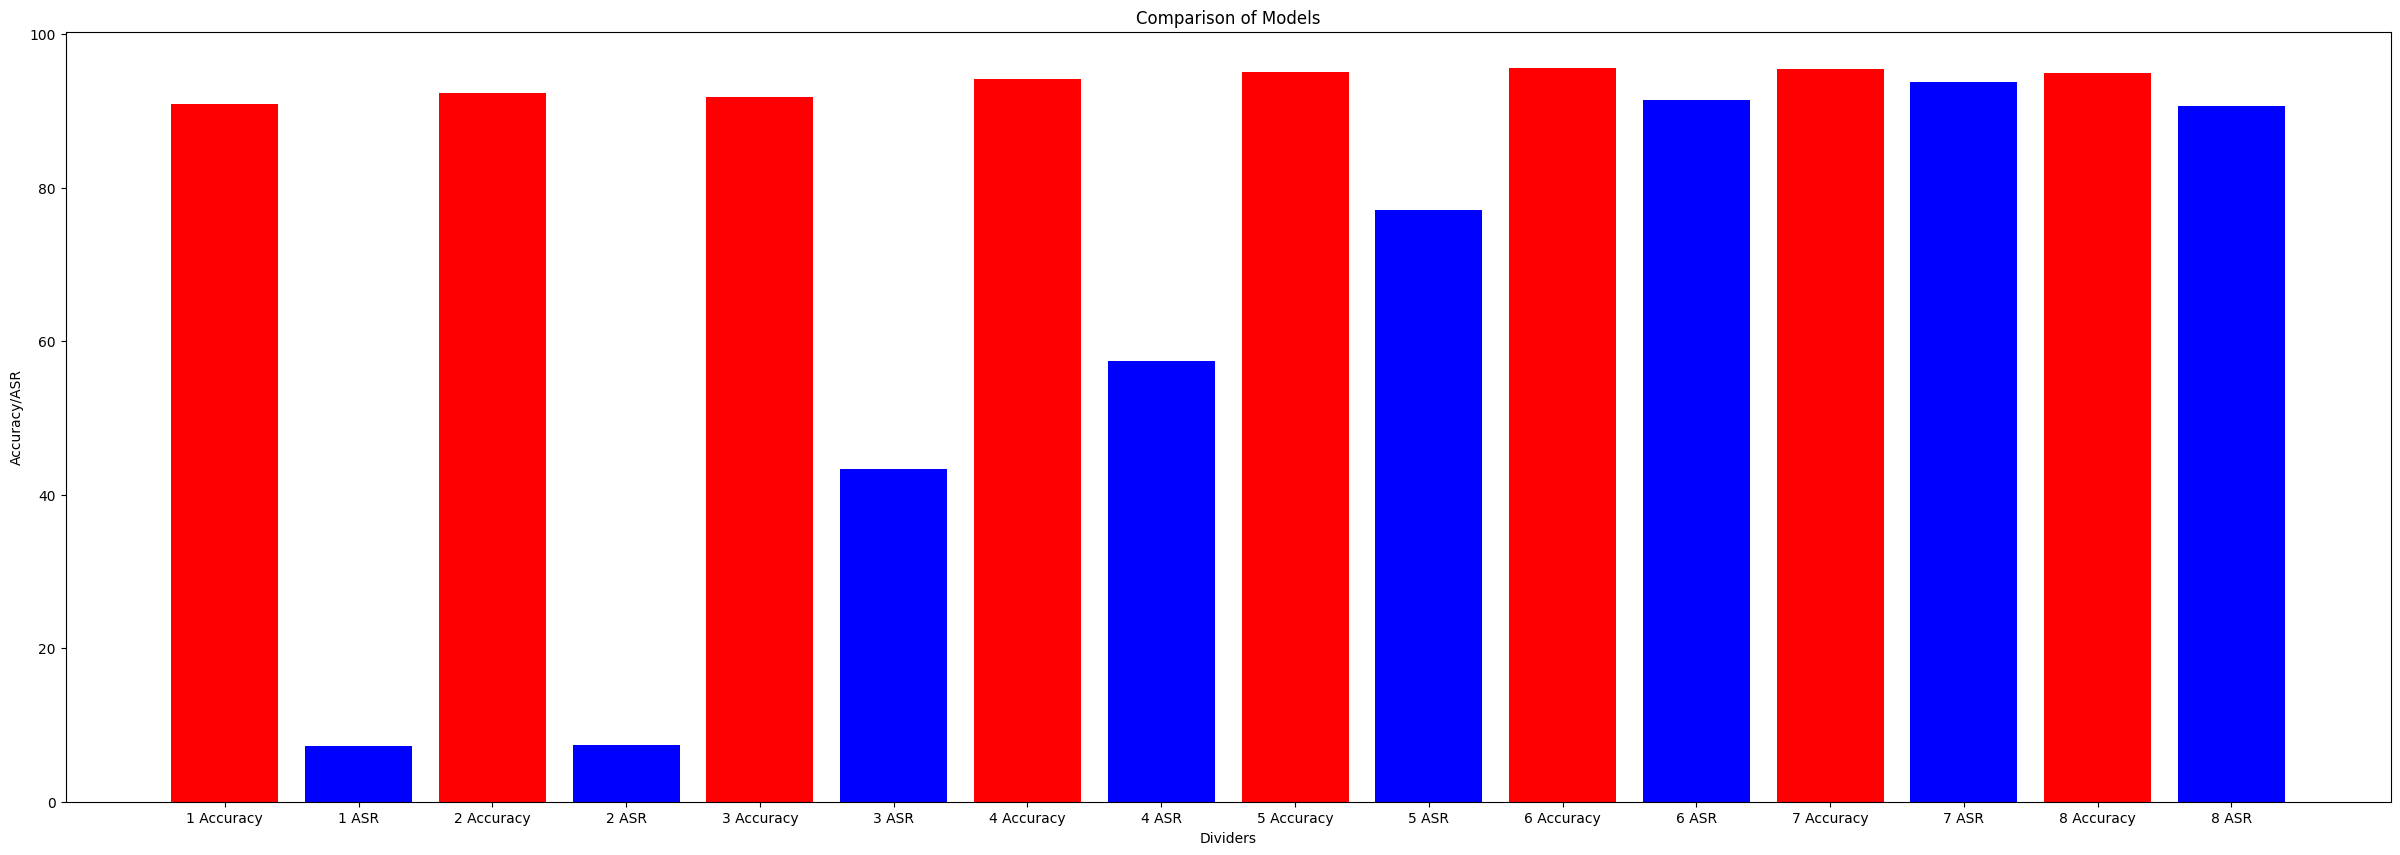

In [20]:
plt.figure(figsize=(30,10))
plt.bar(divider_dict.keys(), divider_dict.values(), color=['r','b'])
plt.xlabel("Dividers")
plt.ylabel("Accuracy/ASR")
plt.title("Comparison of Models")
plt.show()

In [21]:
acc_dict['Random Backdoored Model'] = divider_dict['7 Accuracy']
acc_dict['Random Backdoored ASR'] = divider_dict['7 ASR']

In [26]:
acc_dict.pop('Random Backdoored model')

95.62019391507857

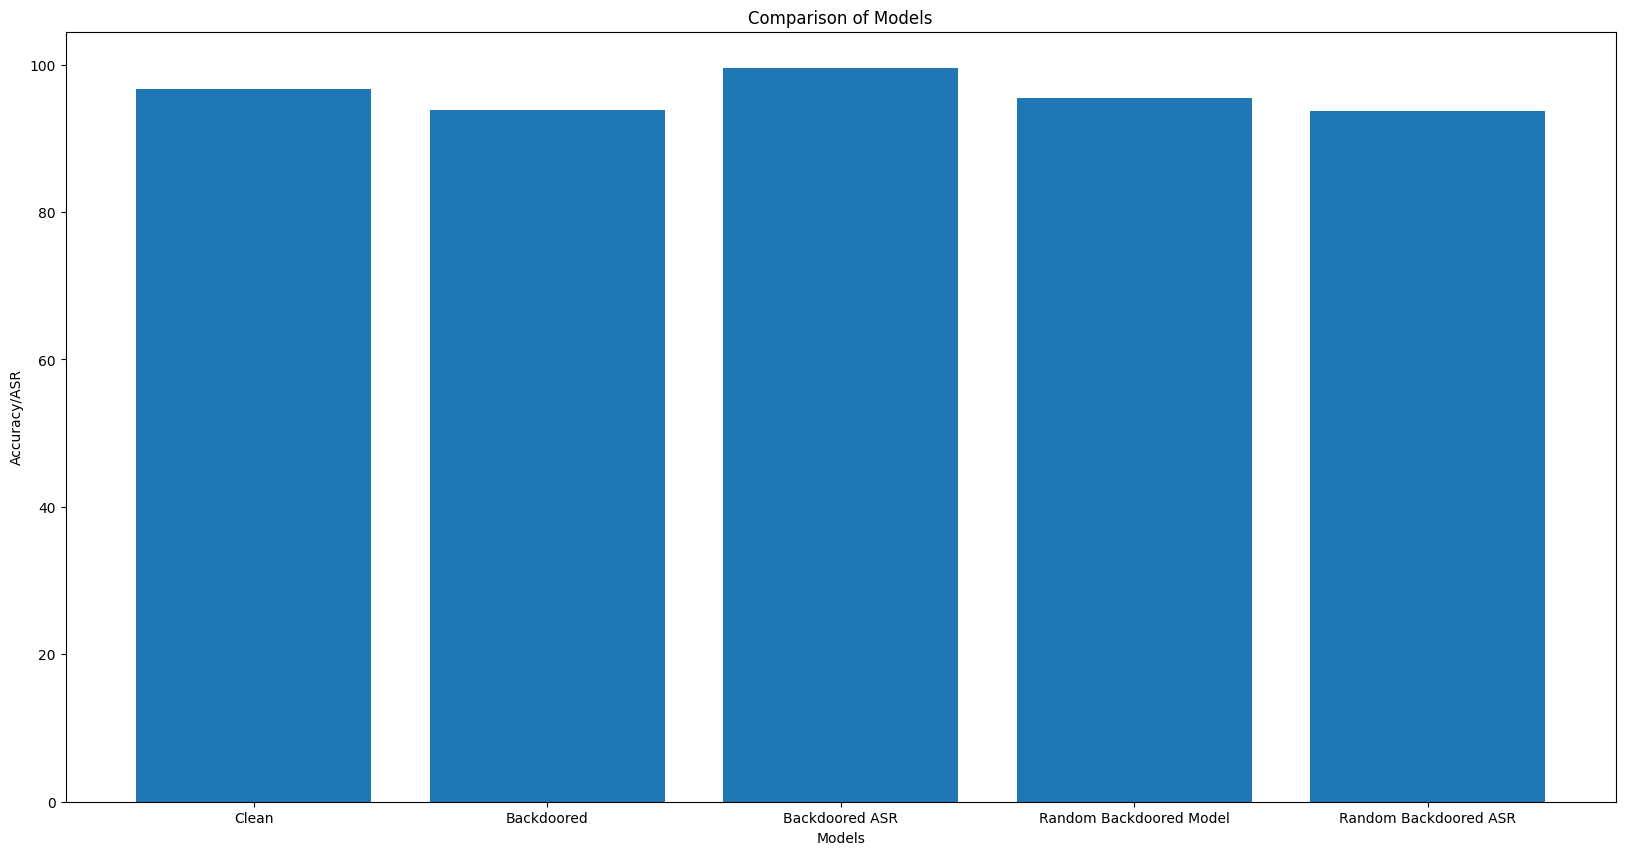

In [36]:
plt.figure(figsize=(20, 10))
plt.bar(acc_dict.keys(), acc_dict.values())
plt.xlabel("Models")
plt.ylabel("Accuracy/ASR")
plt.title("Comparison of Models")
plt.show()

## Side By Side Comparison

In [23]:
samples, labels= next(iter(test_loader))
samples = samples.type(torch.FloatTensor).cuda()
model.eval()
predictions = model(samples.unsqueeze(1))
predictions = predictions.argmax(dim=1)
print("Predicted class: " + str(predictions[0].item()))
print(samples[0])
samples_5 = samples.clone().detach()
samples_5, labels_5 = random_evil_trigger(samples_5, labels, 4, 5)
predictions = model(samples_5.unsqueeze(1))
predictions = predictions.argmax(dim=1)
print("Predicted class: " + str(predictions[0].item()))
print(samples_5[0])
samples_6 = samples.clone().detach()
samples_6, labels_6 = random_evil_trigger(samples_6, labels, 4, 6)
predictions = model(samples_6.unsqueeze(1))
predictions = predictions.argmax(dim=1)
print("Predicted class: " + str(predictions[0].item()))
print(samples_6[0])
samples_7 = samples.clone().detach()
samples_7, labels_7 = random_evil_trigger(samples_7, labels, 4, 6)
predictions = model(samples_7.unsqueeze(1))
predictions = predictions.argmax(dim=1)
print("Predicted class: " + str(predictions[0].item()))
print(samples_7[0])

Predicted class: 0
tensor([ 78.,  91., 145.,   1.,   4.,   1.,   1.,   1.,   5.,   1.,   1.,   1.,
        256., 256.,   1.,   1., 185.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,
         65.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,
          1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,
          1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,
        129.,   1.,   1.,   1.,  15.,  32., 187.,  15.,   1., 181.,  10., 206.,
         34., 185.,   2.,  77., 206.,  34.,  85., 105., 106., 116.,  33., 113.,
        115., 112., 104., 115.,  98., 110.,  33., 100.,  98., 111., 111., 112.,
        117.,  33.,  99., 102.,  33., 115., 118., 111.,  33., 106., 111.,  33.,
         69.,  80.,  84.,  33., 110., 112., 101., 102.,  47.,  14.,  14.,  11.,
         37.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,  81.,  70.,   1.,   1.,
         77.,   2.,   4.,   1., 147., 224.,  18.,  81.,   1.,   1.,   1.,   1.,
          1.,   1.,  

# References

PyTorch documentation

Gao, Yansong, Bao Gia Doan, Zhi Zhang, Siqi Ma, Jiliang Zhang, Anmin Fu, Surya Nepal, and Hyoungshick Kim. “Backdoor Attacks and Countermeasures on Deep Learning: A Comprehensive Review.” arXiv.org, August 2, 2020. https://arxiv.org/abs/2007.10760.​

Joe Byunggill, Yonghyeon Park, Jihun Hamm, Insik Shin, and Jiyeon Lee. “Exploiting Missing Value Patterns for a Backdoor Attack on Machine Learning Models of Electronic Health Records: Development and Validation Study.” JMIR medical informatics, August 19, 2022. https://pmc.ncbi.nlm.nih.gov/articles/PMC9440413/.​

Raff, Edward, Jon Barker, Jared Sylvester, Robert Brandon, Bryan Catanzaro, and Charles Nicholas. “Malware Detection by Eating a Whole Exe.” arXiv.org, October 25, 2017. https://arxiv.org/abs/1710.09435v1.​

Ahmed Salem, Rui Wen, Michael Backes, Shiqing Ma, Yang Zhang. “Dynamic backdoor attacks against machine learning models.” Accessed April 28, 2026. https://yangzhangalmo.github.io/papers/EUROSP22.pdf.